In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import logging
import os
import warnings
import itertools
from datetime import datetime, timedelta
from functools import partial
from pathlib import Path
from optimization_engines import dwave_quantum_sharpe_minimize

SEED = 12
np.random.seed(SEED)
msg_level = logging.INFO
# Suppress all RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Quantum Portfolio Optimization using D-Wave CQM Solver

In [2]:
# Create a logger
logger = logging.getLogger("inspect_results_logger")
logger.setLevel(msg_level)  # Set the level for this logger

# Create a handler (where to send the logs)
handler = logging.StreamHandler()  # Send to the console
handler.setLevel(msg_level)

# Create a formatter (how to format the logs)
formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")
handler.setFormatter(formatter)

# Add the handler to the logger
logger.addHandler(handler)

### Path definition

In [3]:
benchmark_path = '../../data/benchmark_gspc.pkl'
source_path = '../../data/stocks_adjclose.pkl'

### Data loading

Ticker,ds,^GSPC
0,2011-01-03,1271.869995
1,2011-01-04,1270.199951
2,2011-01-05,1276.560059
3,2011-01-06,1273.849976
4,2011-01-07,1271.500000


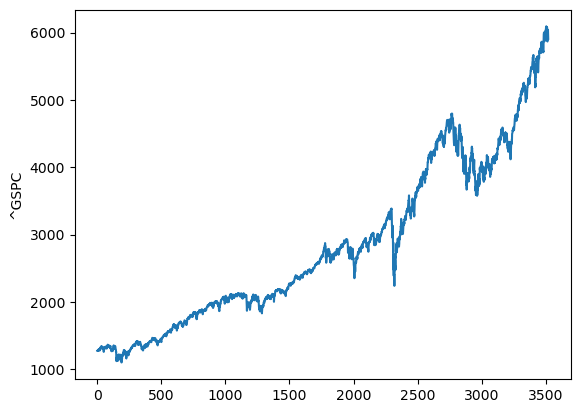

In [4]:
benchmark = pd.read_pickle(benchmark_path)
sns.lineplot(benchmark['^GSPC'])
benchmark.head()

In [5]:
source = pd.read_pickle(source_path)
print(source.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source.isnull().values.any()
print("Any NaN in source_wide:", has_any_nan)
source.head()

(3522, 439)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,6.112024,18.971697,71.104691,11.828708,76.192101,14.700940,43.098133,26.977388,47.841393,38.200001
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,6.072278,18.631702,69.911537,11.702991,78.568939,14.763333,43.300457,26.565216,47.206047,37.840000
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,6.045782,18.713308,70.882263,12.068158,79.582596,14.675976,43.184826,26.691620,47.240875,37.799999
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,5.977333,18.577297,71.084503,11.984348,80.162842,14.663502,43.462337,26.878460,45.778728,37.480000
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,5.939793,18.486635,70.963158,12.313586,83.001091,14.794533,43.699345,27.213682,45.770027,37.599998


### Correlation Analysis

* Determine a set of stocks with minimal correlation

In [6]:
df_corr = source.corr()
df_corr.head()

Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Ticker,,,,,,,,,,,,,,,,,,,,,
A,1.000000,0.938434,0.972057,0.803930,0.973666,0.944446,0.958391,0.877209,0.950709,0.946486,...,0.915526,0.962450,0.952409,0.840455,-0.192150,0.925082,0.581125,0.957106,0.742547,0.926361
AAPL,0.938434,1.000000,0.925958,0.904199,0.965640,0.912658,0.974905,0.858673,0.957237,0.883810,...,0.954041,0.944027,0.944347,0.799052,-0.274004,0.864298,0.709763,0.932155,0.609996,0.834967
ABT,0.972057,0.925958,1.000000,0.780764,0.974008,0.966874,0.947089,0.840192,0.947416,0.967112,...,0.905557,0.957242,0.959083,0.826124,-0.199613,0.959269,0.502779,0.961910,0.787986,0.938066
ACGL,0.803930,0.904199,0.780764,1.000000,0.859009,0.772929,0.921957,0.746998,0.908116,0.731481,...,0.943648,0.783657,0.889515,0.726342,-0.175307,0.746701,0.854873,0.878777,0.539229,0.617688
ACN,0.973666,0.965640,0.974008,0.859009,1.000000,0.962718,0.975225,0.861665,0.975261,0.940212,...,0.947315,0.970085,0.967641,0.856489,-0.227554,0.926912,0.623003,0.971591,0.727454,0.899654


#### Rank correlation ascending

In [7]:
# rank by correlation
corr_sum = df_corr.map(lambda x: abs(x)).sum()
corr_rank = corr_sum.sort_values().rank(method='min').astype(int)
corr_rank

Ticker
TPR       1
BKR       2
GE        3
WYNN      4
DVN       5
       ... 
TXN     435
TEL     436
ITW     437
ICE     438
HD      439
Length: 439, dtype: int64

#### Rank returns descending

In [8]:
# rank by returns
return_rank = source.diff().sum(axis=0).sort_values().rank(method='min', ascending=False).astype(int)
return_rank

Ticker
APA     439
MOS     438
SLB     437
DVN     436
PCG     435
       ... 
TDG       5
FICO      4
AZO       3
BKNG      2
NVR       1
Length: 439, dtype: int64

### Portfolio Stats

In [9]:
def portfolio_stats(weights, data):

    weights = np.array(weights)
    returns = np.log(data) - np.log(data.shift(1)) # log return to minimize fp error
    # CONSISTENT: Always use log returns, never pct_change()
    port_return = np.sum(returns.mean() * weights) 
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() , weights)))
    try:
        sharpe_ratio = port_return/port_vol
    except Exception as e:
        sharpe_ratio = 0
    return sharpe_ratio, port_return, port_vol

### Data generator

Data generator to instantiate blocks on demand

In [10]:
def generate_data(df, benchmark, days_to_avg=30, days_to_opt=30, seed=SEED):
    df2 = df.reset_index()
    benchmark2 = benchmark.reset_index()
    elements = df2.sample(n=100, random_state=seed).index # definint a maximum of 100 different sampled initial dates
    for idx in elements:
        df_sample = df2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample = df_sample.set_index('ds')
        df_sample_b = benchmark2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample_b = df_sample_b.set_index('ds').drop(['index'], axis=1)
        yield df_sample, df_sample_b

### Backtest

In [11]:
def backtest(optimization_function, data, benchmark, initial_capital, avg_period, opt_period):
    portfolio_value = initial_capital
    portfolio_returns = []
    benchmark_returns = []
    portfolio_total_return = []
    portfolio_sharpe_ratios = []
    weights_history = pd.DataFrame(index=data.index, columns=data.columns)
    portfolio_value_history = pd.Series(index=data.index, name='Portfolio Value', dtype='float')
    portfolio_value_history.iloc[0] = portfolio_value


    j = 0
    for i in range(avg_period+1, avg_period + opt_period+1):
        df = data.iloc[j:i, :]
        # Use log returns for consistency with optimization functions
        df_log_returns = np.log(df) - np.log(df.shift(1))
        df_log_returns = df_log_returns.dropna(axis=0)
        #logger.debug(f'df_log_returns: {df_log_returns}')
        weights = optimization_function(df)
        weights[weights < 0] = 0
        weights /= weights.sum()
        weights_history.loc[df.index[-1]] = weights
        #sharpe_ratio, portfolio_return, portfolio_volatility = portfolio_stats(weights, df)
        # portfolio_change = df.iloc[-2:, :].pct_change() * weights
        portfolio_change = df_log_returns.iloc[-1] * weights
        #portfolio_return = portfolio_change.sum(axis=1).iloc[-1]
        portfolio_return = portfolio_change.sum()
        portfolio_returns.append(portfolio_return)
        # print(f'portfolio returns: {portfolio_returns}')
        # Use log returns for benchmark as well
        benchmark_log_returns = np.log(benchmark.iloc[j:i, :]) - np.log(benchmark.iloc[j:i, :].shift(1))
        benchmark_return = benchmark_log_returns.iloc[-1].values.tolist()[0]
        benchmark_returns.append(benchmark_return)
        # print(f'benchmark_returns: {benchmark_returns}')
        portfolio_cumulative_returns = np.cumprod([k + 1 for k in portfolio_returns])
        # print(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
        benchmark_cumulative_returns = np.cumprod([k + 1 for k in  benchmark_returns])
        # print(f'benchmark cumulative returns: {benchmark_cumulative_returns}')
        portfolio_mean_return = np.mean(portfolio_returns)
        benchmark_mean_return = np.mean(benchmark_returns)
        portfolio_volatility = np.std(portfolio_returns) 
        benchmark_volatility = np.std(benchmark_returns)
        try:
            sharpe_ratio = (portfolio_mean_return) / portfolio_volatility
        except Exception as e:
            sharpe_ratio = 0
        portfolio_sharpe_ratios.append(sharpe_ratio)

         # Portfolio & Benchmark value
        benchmark_value = initial_capital * benchmark_cumulative_returns[-1]
        portfolio_value = initial_capital * portfolio_cumulative_returns[-1]
        j += 1

    portfolio_cumulative_returns = portfolio_cumulative_returns - portfolio_cumulative_returns[0]
    benchmark_cumulative_returns = benchmark_cumulative_returns - benchmark_cumulative_returns[0]

    # Plot the results
    plt.figure(figsize=(12, 6))
    plt.plot(portfolio_cumulative_returns, label='Portfolio')
    plt.plot(benchmark_cumulative_returns, label='Benchmark')
    #plt.plot(portfolio_returns, label='Portfolio')
    #plt.plot(benchmark_returns, label='Benchmark')
    plt.legend(loc='upper left')
    plt.title('Backtesting Results')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Returns')
    plt.show()

    return weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns

In [12]:
import pickle

def write_pickle_dict(data, file_path):
    """Pickles a dictionary and saves it to a file."""
    try:
        with open(file_path, 'wb') as f:  # Open the file in binary write mode ('wb')
            pickle.dump(data, f)
        print(f"Dictionary pickled and saved to {file_path}")
    except Exception as e:
        print(f"An error occurred while pickling: {e}")

def read_pickle_dict(file_path):
    try:
        with open(file_path, 'rb') as f:
            loaded_dict = pickle.load(f)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")
    return loaded_dict


### Run Experiment Function

In [13]:
def run_experiment(results_path_template, data, benchmark, opt_fun, parameters):

    n_periods = parameters['n_periods']
    days_to_avg = parameters['days_to_avg']
    days_to_opt = parameters['days_to_opt']
    initial_capital = parameters['initial_capital']
    datagen = generate_data(data, benchmark)

        
    for i in range(n_periods):
        results_path = results_path_template.format(i)
        if not os.path.exists(results_path):
            try:
                df, df_b = next(datagen)
                print(f'initial date: {df.iloc[days_to_avg+1:, :].index[0]}')
                plt.figure(figsize=(12, 6))
                plt.plot(df.iloc[days_to_avg+1:days_to_avg+days_to_opt+1, :].sum(axis=1), label='Source')
                plt.plot(df_b, label='Benchmark')
                plt.legend(loc='upper left')
                plt.title('Source Data')
                plt.xlabel('Date')
                plt.ylabel('Stock Values')
                plt.show()
                start_time = datetime.now()
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = backtest(opt_fun, df, df_b, initial_capital=initial_capital, avg_period=days_to_avg,opt_period=days_to_opt)
                logger.debug(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
                end_time = datetime.now()
                dt = abs(end_time - start_time)
            except Exception as e: 
                print(f'Failed {results_path} due to {e}')
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = [], [], [], []

            result = {
                "round": i, 
                "start_date": df.index[0],
                "end_date": df.index[-1],
                "days_to_avg": days_to_avg,
                "days_to_opt": days_to_opt,
                "weights_history": weights_history,
                "portfolio_value_history": portfolio_value_history,
                "portfolio_cumulative_returns": portfolio_cumulative_returns,
                "benchmark_cumulative_returns": benchmark_cumulative_returns,
                "total_run_time": dt.total_seconds()
                }
            write_pickle_dict(result, results_path)

        else:
            results = read_pickle_dict(results_path)
            portfolio_cumulative_returns = results['portfolio_cumulative_returns']
            benchmark_cumulative_returns = results['benchmark_cumulative_returns']

            # Plot the results
            plt.figure(figsize=(12, 6))
            plt.plot(portfolio_cumulative_returns, label='Portfolio')
            plt.plot(benchmark_cumulative_returns, label='Benchmark')
            plt.legend(loc='upper left')
            plt.title('Backtesting Results')
            plt.xlabel('Date')
            plt.ylabel('Cumulative Returns')
            plt.show()
            
    return None

### Performance Analysis Functions

In [14]:
def performance_summary(solver_configs, n_periods):
    """Generate performance summary across all periods for multiple solvers."""
    summary_data = []
    
    for config in solver_configs:
        solver_name = config['name']
        path_template = config['path_template']
        
        returns_data = []
        execution_times = []
        successful_periods = 0
        
        for period in range(n_periods):
            file_path = path_template.format(period)
            try:
                result_data = read_pickle_dict(file_path)
                if result_data is not None:
                    portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
                    execution_time = result_data.get('total_run_time', 0)
                    
                    # Safe check for portfolio returns data
                    try:
                        if portfolio_returns is not None and len(portfolio_returns) > 0:
                            final_return = portfolio_returns[-1]
                            returns_data.append(final_return)
                            execution_times.append(execution_time)
                            successful_periods += 1
                    except (TypeError, IndexError):
                        pass
            except Exception as e:
                logger.debug(f'Could not process {file_path}: {e}')
        
        if returns_data:
            summary_data.append({
                'Solver': solver_name,
                'Periods': successful_periods,
                'Avg_Return': np.mean(returns_data),
                'Std_Return': np.std(returns_data),
                'Min_Return': np.min(returns_data),
                'Max_Return': np.max(returns_data),
                'Avg_Time': np.mean(execution_times),
                'Std_Time': np.std(execution_times),
                'Success_Rate': successful_periods / n_periods * 100
            })
    
    if summary_data:
        df = pd.DataFrame(summary_data)
        df = df.round(4)
        return df
    else:
        return pd.DataFrame()

### Global Parameters

CQM-specific parameters for quantum optimization

In [15]:
parameters = {
    "n_periods": 10,
    "days_to_avg": 30,
    "days_to_opt": 30,
    "initial_capital": 1_000_000,
    "budget": 1.0,
    "min_investment": 0.001,
}

### Test 1: Quantum Optimization with Full Dataset

In [16]:
# D-Wave Quantum NLP Optimization - Define the optimization function
opt_fun_cqm = partial(dwave_quantum_sharpe_minimize, 
                     budget=parameters["budget"], 
                     min_investment=parameters["min_investment"])

# Extract n_periods for use in performance analysis
n_periods = parameters['n_periods']

print(f"D-Wave quantum optimization function created with parameters:")
print(f"  budget: {parameters['budget']}")
print(f"  min_investment: {parameters['min_investment']}")
print(f"  n_periods: {n_periods}")

D-Wave quantum optimization function created with parameters:
  budget: 1.0
  min_investment: 0.001
  n_periods: 10


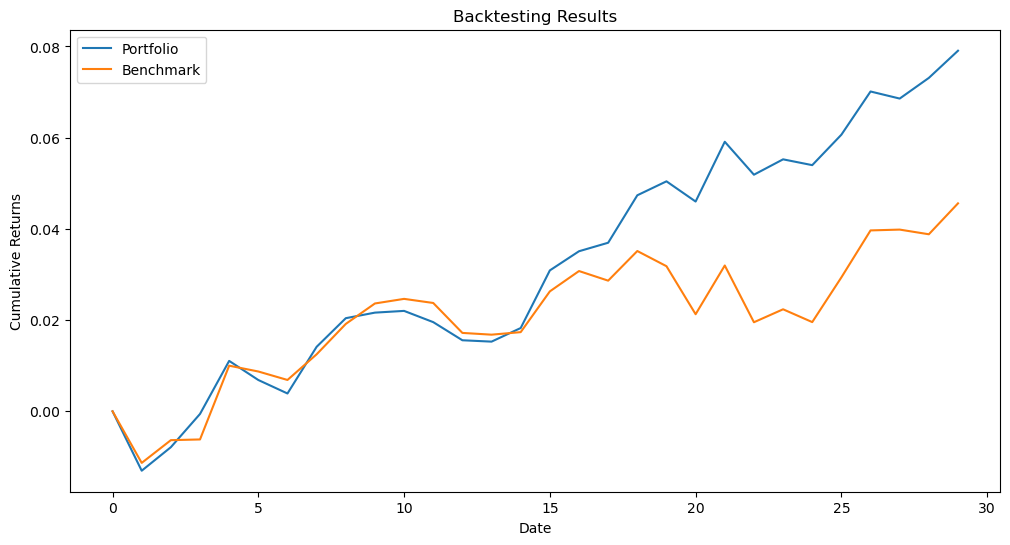

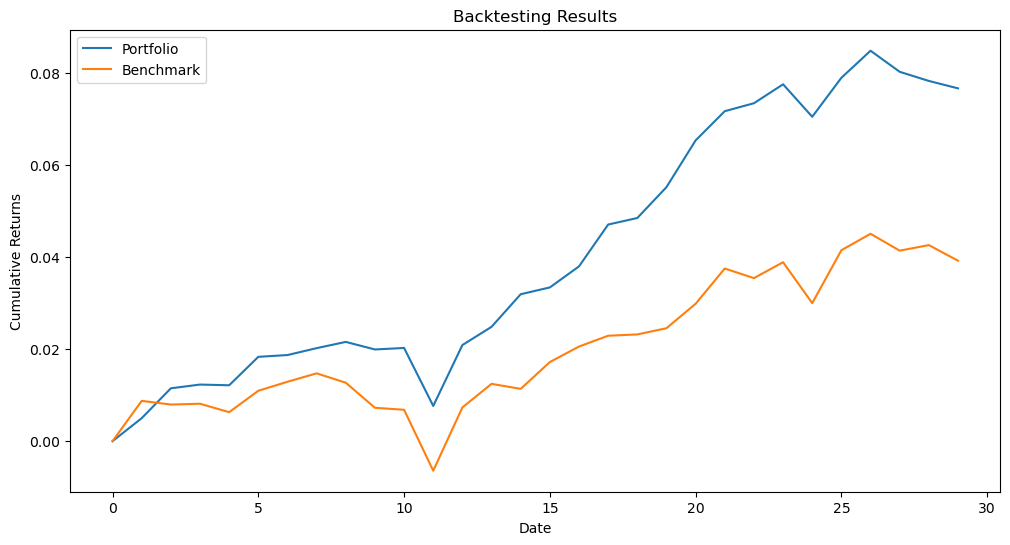

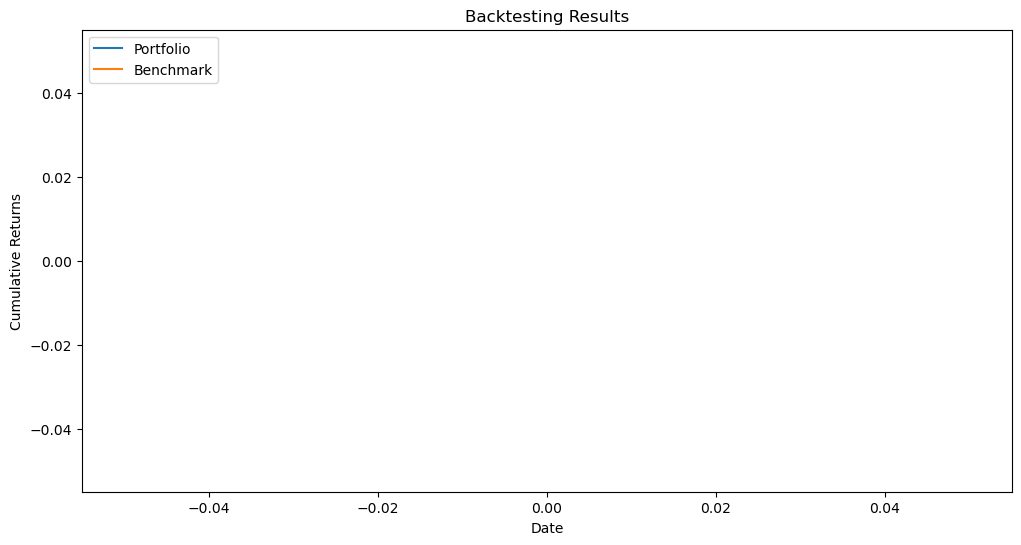

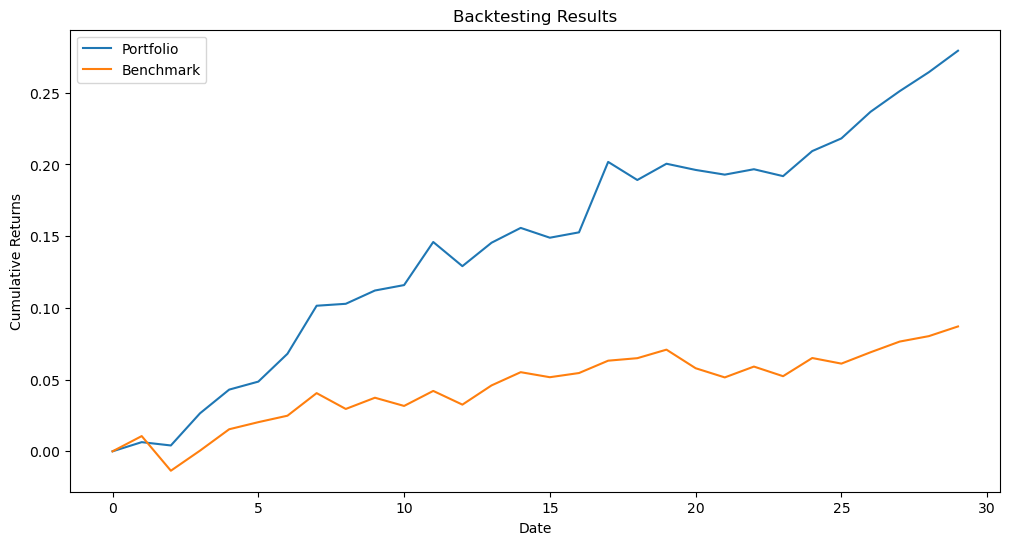

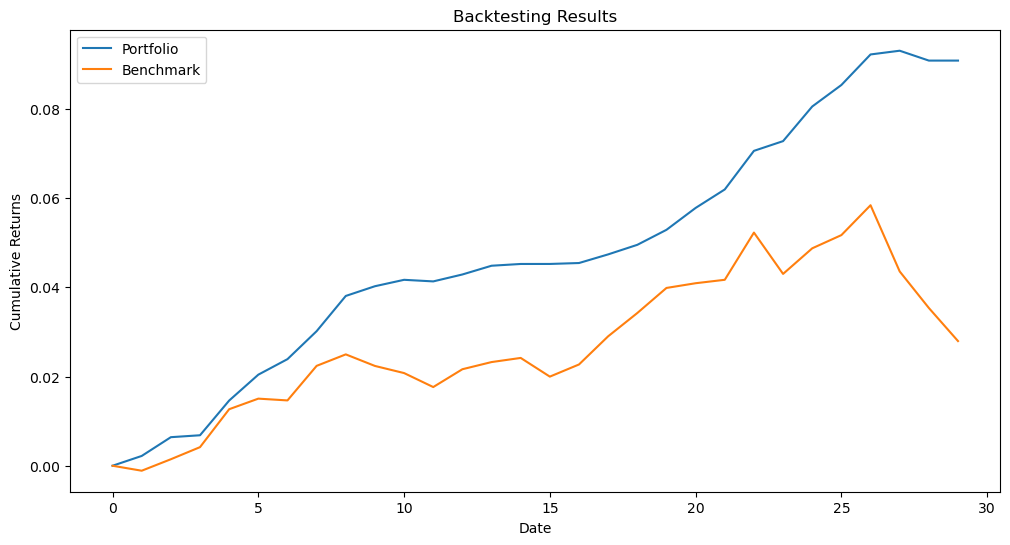

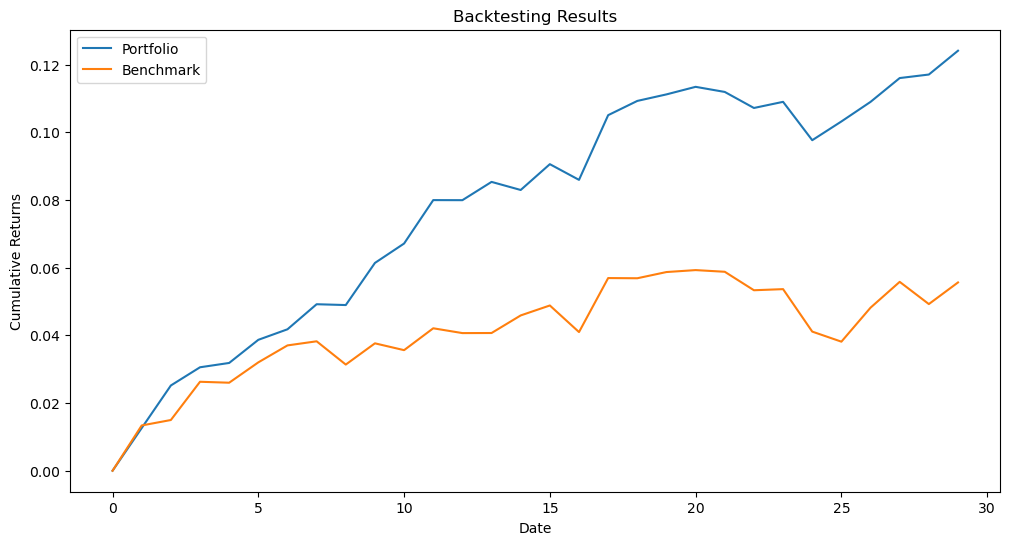

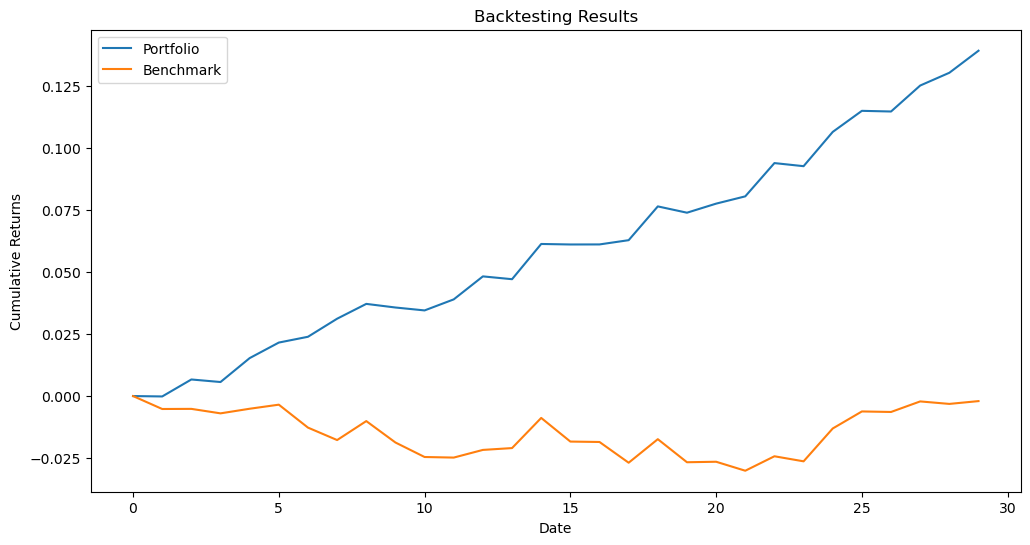

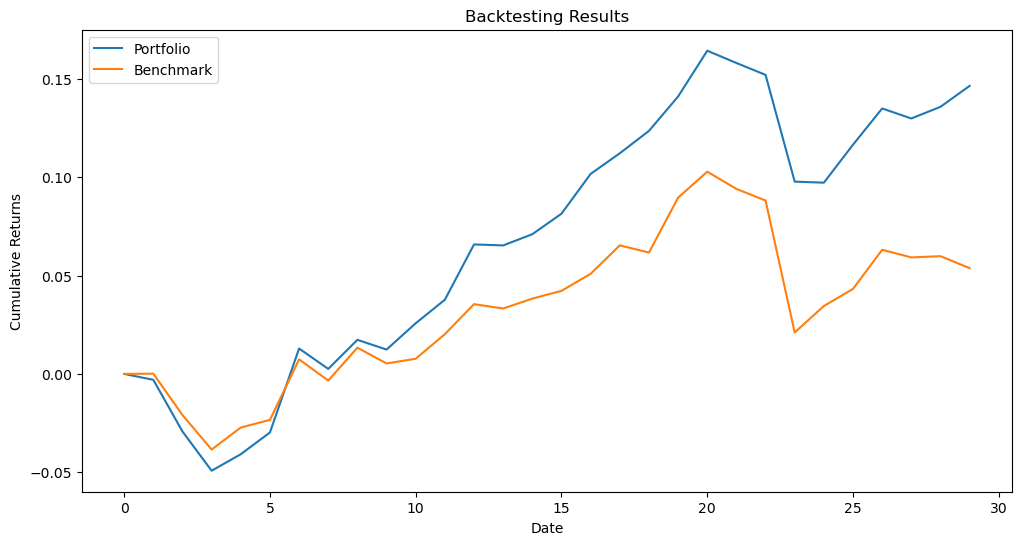

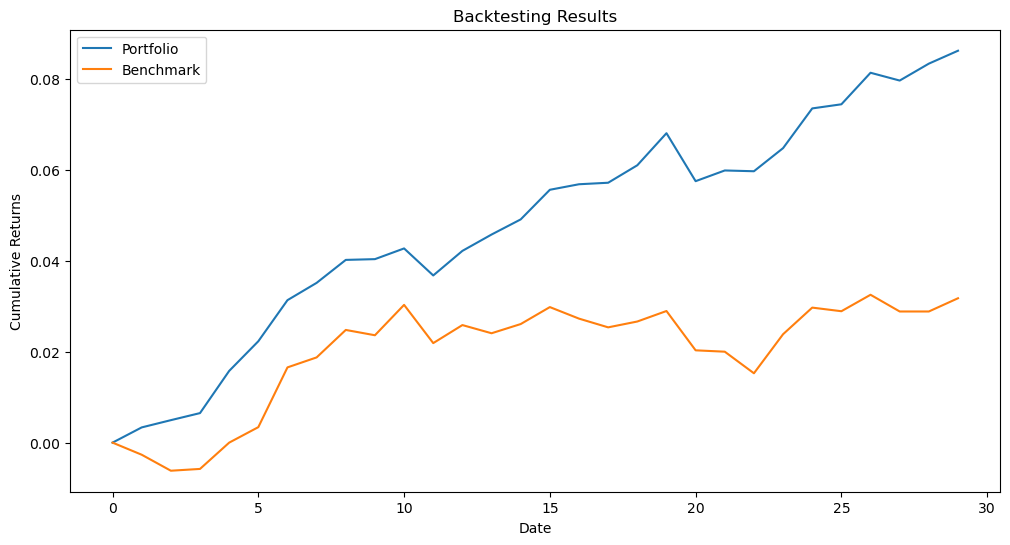

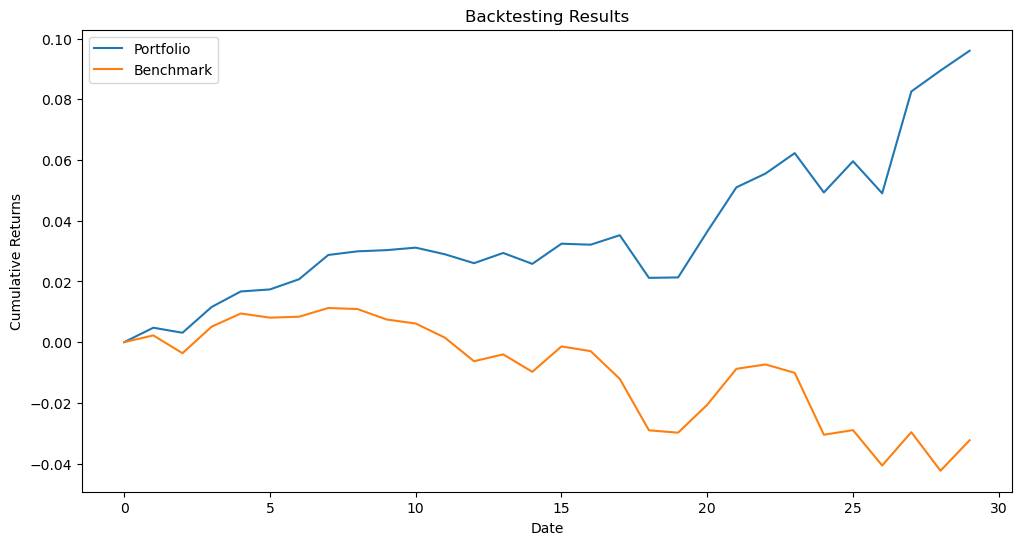

In [17]:
results_path_cqm_full = '../../results/sharpe_optimization/results_full_{}_cqm.pkl'
_ = run_experiment(results_path_cqm_full, source, benchmark, opt_fun_cqm, parameters)

#### Performance Analysis for Full Dataset

In [18]:
# Performance analysis for CQM optimization (Full Dataset)
cqm_full_solvers = [
    {'path_template': '../../results/sharpe_optimization/results_full_{}_cqm.pkl', 'name': 'D-Wave CQM Sharpe'},
]

print("\n" + "="*100)
print("COMPREHENSIVE PERFORMANCE SUMMARY - D-Wave CQM Optimization (Full Dataset)")
print("="*100)
summary_df = performance_summary(cqm_full_solvers, n_periods)
if not summary_df.empty:
    display(summary_df)
    
    # Performance analysis
    print("\nPerformance Analysis:")
    print("-" * 50)
    print(f"Successful periods: {summary_df.iloc[0]['Periods']}/{n_periods}")
    print(f"Average return: {summary_df.iloc[0]['Avg_Return']:.4f}")
    print(f"Average execution time: {summary_df.iloc[0]['Avg_Time']:.2f}s")
    print(f"Success rate: {summary_df.iloc[0]['Success_Rate']:.1f}%")
else:
    print("No summary data available")


COMPREHENSIVE PERFORMANCE SUMMARY - D-Wave CQM Optimization (Full Dataset)


,Solver,Periods,Avg_Return,Std_Return,Min_Return,Max_Return,Avg_Time,Std_Time,Success_Rate
0,D-Wave CQM Sharpe,9,0.1242,0.06,0.0767,0.2793,125.9507,18.5966,90.0



Performance Analysis:
--------------------------------------------------
Successful periods: 9/10
Average return: 0.1242
Average execution time: 125.95s
Success rate: 90.0%


## Test 2: Wide Dataset (Stocks + ETFs)

In [19]:
source_path_extended = '../../data/etfs_close.pkl'

In [20]:
source_extended = pd.read_pickle(source_path_extended)
source_extended.head()

Ticker,ds,AADR,ACWI,ACWX,AFG,AGG,AMLP,BIL,BIV,BND,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
0,2011-01-03,26.494179,35.018154,30.182961,14.173727,71.489235,26.573900,76.281036,50.488926,53.083935,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
1,2011-01-04,26.450108,34.981026,30.019852,14.104879,71.509521,26.491484,76.281036,50.562424,53.090553,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2,2011-01-05,26.291458,34.981026,29.992662,14.066156,71.164383,26.458506,76.281036,50.188774,52.858776,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
3,2011-01-06,26.291458,34.758274,29.727602,14.264087,71.177925,26.458506,76.281036,50.378658,52.905167,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
4,2011-01-07,26.150438,34.632030,29.578085,14.195246,71.408035,26.491484,76.264374,50.678814,53.103794,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


In [21]:
source_wide = pd.merge(source, source_extended, on='ds', how='left').set_index('ds').dropna()
print(source_wide.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source_wide.isnull().values.any()
print("Any NaN in source_wide:", has_any_nan)
source_wide.head()

(3521, 680)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


#### D-Wave Quantum NLP Optimization

initial date: 2014-01-13 00:00:00


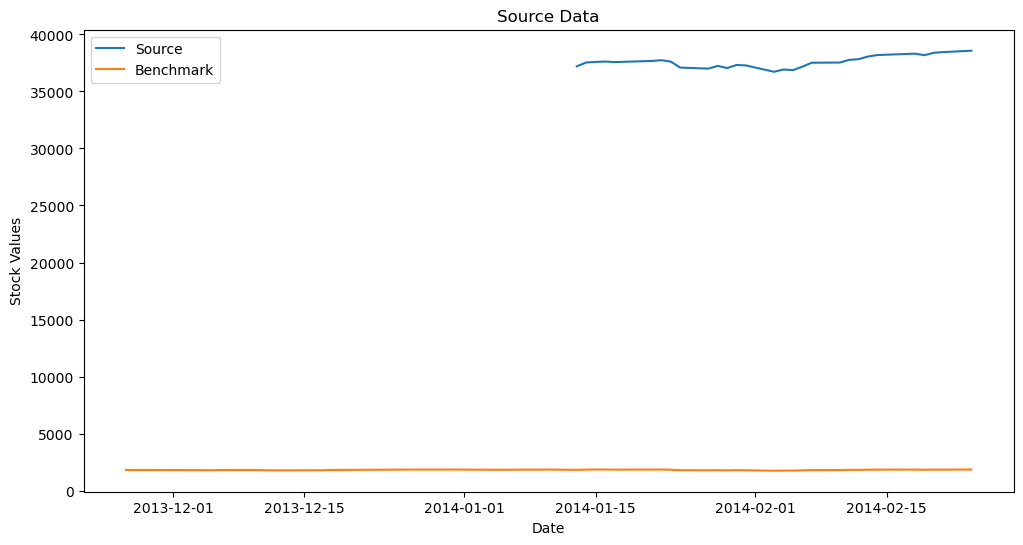

Total investment: <dwave.optimization.symbols.NaryAdd at 0x36549cf8>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x3285ade8>


2025-09-02 22:00:16,252 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x325ce388>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:00:24,416 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:00:24,417 - inspect_results_logger - INFO - Final Sharpe ratio: 0.652289
2025-09-02 22:00:24,417 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:00:24,418 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x4ca53a48>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x4cb0b2c8>


...

2025-09-02 22:06:50,900 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:06:50,900 - inspect_results_logger - INFO - Final Sharpe ratio: 0.812146
2025-09-02 22:06:50,901 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:06:50,901 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x41874528>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x4192bd78>


2025-09-02 22:06:56,257 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x41b19438>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:07:03,491 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:07:03,492 - inspect_results_logger - INFO - Final Sharpe ratio: 0.915532
2025-09-02 22:07:03,492 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:07:03,493 - inspect_results_logger - INFO - All weights >= min_investment: True


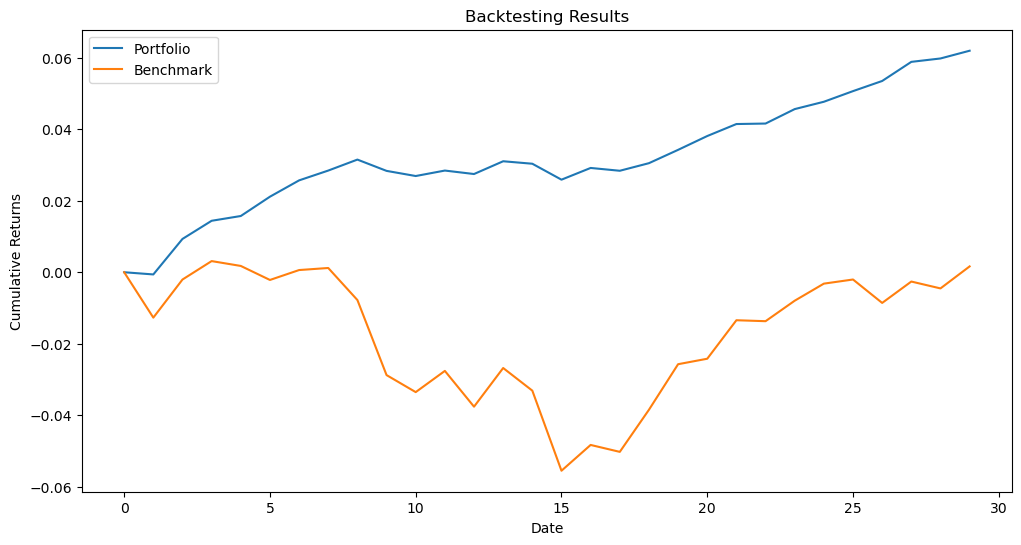

Dictionary pickled and saved to ../../results/sharpe_optimization/results_wide_0_cqm.pkl
initial date: 2023-02-03 00:00:00


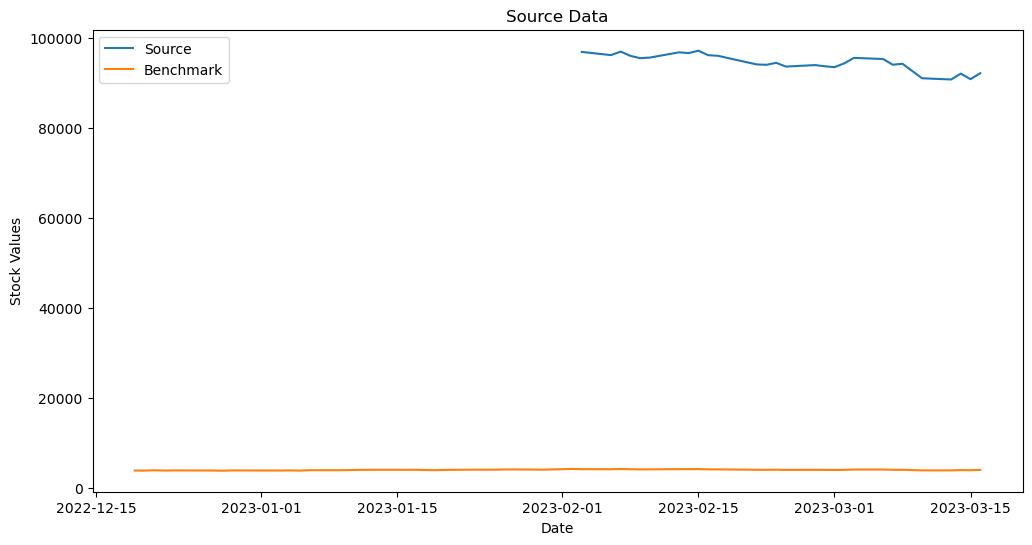

Total investment: <dwave.optimization.symbols.NaryAdd at 0x40f6c7f8>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x3fec4948>


2025-09-02 22:07:08,807 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x45fd8558>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:07:13,802 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:07:13,802 - inspect_results_logger - INFO - Final Sharpe ratio: 0.570655
2025-09-02 22:07:13,802 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:07:13,802 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x47619ca8>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x476d1798>


...

2025-09-02 22:12:22,723 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:12:22,723 - inspect_results_logger - INFO - Final Sharpe ratio: 0.397950
2025-09-02 22:12:22,724 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:12:22,724 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x49599fe8>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x496516e8>


2025-09-02 22:12:27,873 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x43445568>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:12:33,315 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:12:33,315 - inspect_results_logger - INFO - Final Sharpe ratio: 0.336929
2025-09-02 22:12:33,316 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:12:33,316 - inspect_results_logger - INFO - All weights >= min_investment: True


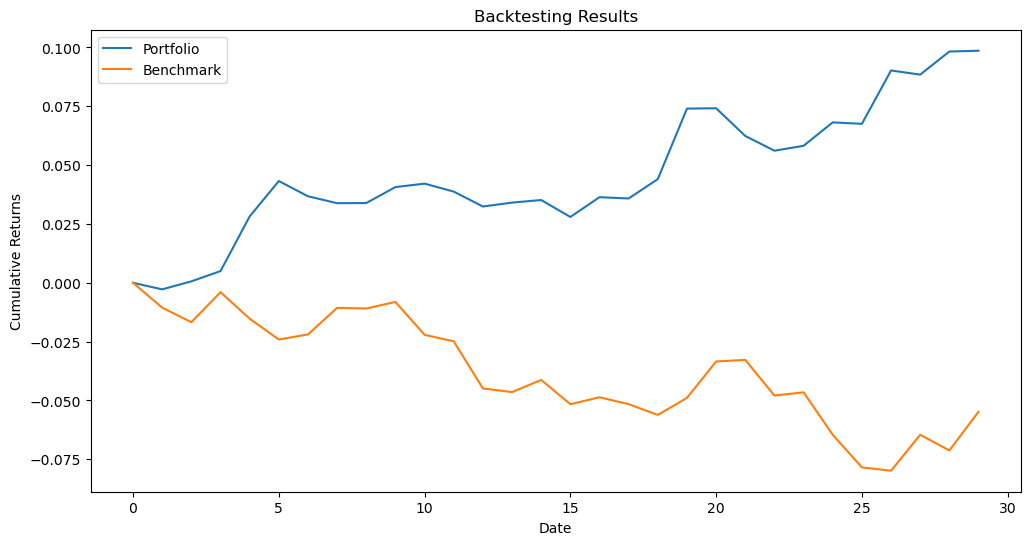

Dictionary pickled and saved to ../../results/sharpe_optimization/results_wide_1_cqm.pkl
initial date: 2024-03-04 00:00:00


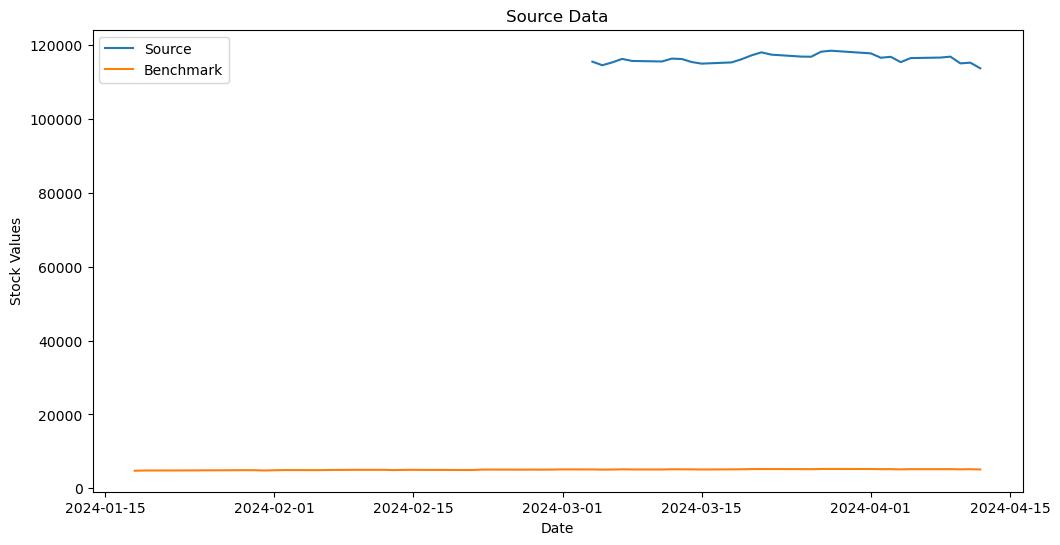

Total investment: <dwave.optimization.symbols.NaryAdd at 0x39c7a8e8>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x331a70b8>


2025-09-02 22:12:38,747 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x32147b28>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:12:46,755 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:12:46,755 - inspect_results_logger - INFO - Final Sharpe ratio: 0.697844
2025-09-02 22:12:46,756 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:12:46,756 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x38d484f8>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x38dffff8>


...

Total investment: <dwave.optimization.symbols.NaryAdd at 0x369ff698>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x36ab6bc8>


2025-09-02 22:15:08,655 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x426f4ef8>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:15:23,275 - inspect_results_logger - ERROR - Optimization failed: Positive directional derivative for linesearch
2025-09-02 22:15:23,275 - inspect_results_logger - ERROR - D-Wave solver encountered an error: D-Wave optimization solver failed: Positive directional derivative for linesearch


Failed ../../results/sharpe_optimization/results_wide_2_cqm.pkl due to D-Wave quantum portfolio optimization failed: D-Wave optimization solver failed: Positive directional derivative for linesearch
Dictionary pickled and saved to ../../results/sharpe_optimization/results_wide_2_cqm.pkl
initial date: 2021-09-22 00:00:00


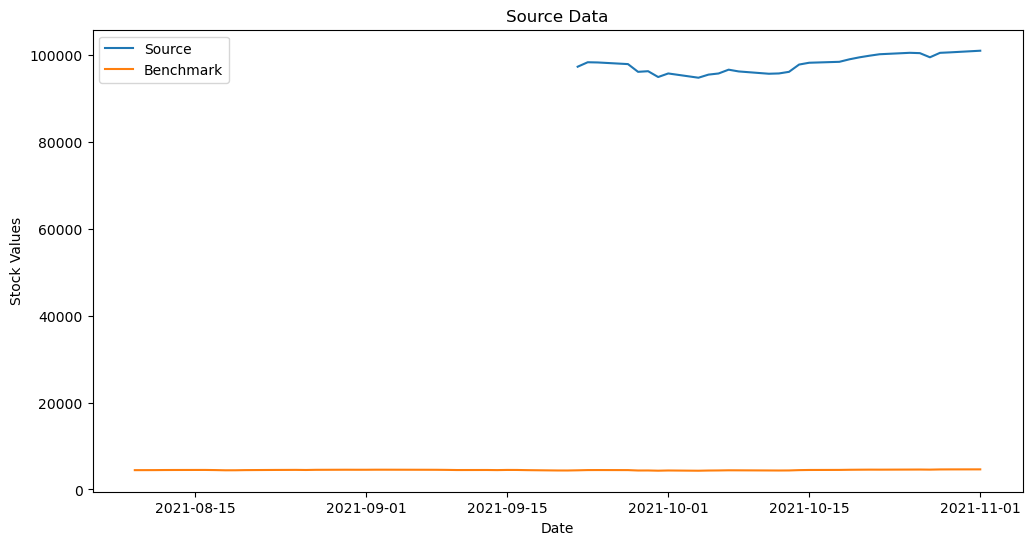

Total investment: <dwave.optimization.symbols.NaryAdd at 0x4a500568>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x393450d8>


2025-09-02 22:15:28,448 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x395350f8>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:15:34,830 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:15:34,831 - inspect_results_logger - INFO - Final Sharpe ratio: 0.309913
2025-09-02 22:15:34,831 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:15:34,831 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x47d826f8>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x4bd2f948>


...

2025-09-02 22:20:13,547 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:20:13,547 - inspect_results_logger - INFO - Final Sharpe ratio: 0.465414
2025-09-02 22:20:13,548 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:20:13,548 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x4b96cb38>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x4ba24348>


2025-09-02 22:20:17,199 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x3944cd48>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:20:21,023 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:20:21,024 - inspect_results_logger - INFO - Final Sharpe ratio: 0.710480
2025-09-02 22:20:21,024 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:20:21,025 - inspect_results_logger - INFO - All weights >= min_investment: True


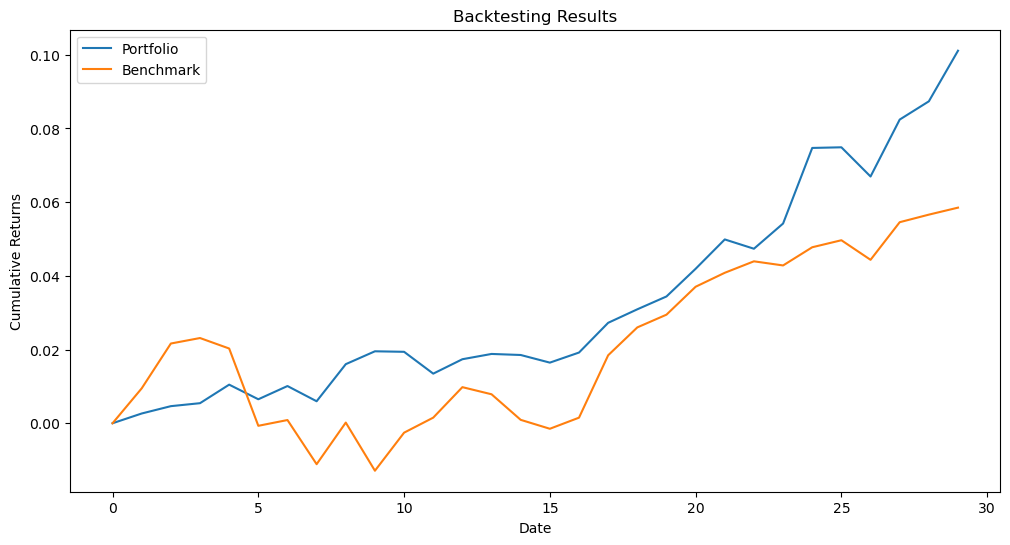

Dictionary pickled and saved to ../../results/sharpe_optimization/results_wide_3_cqm.pkl
initial date: 2024-06-06 00:00:00


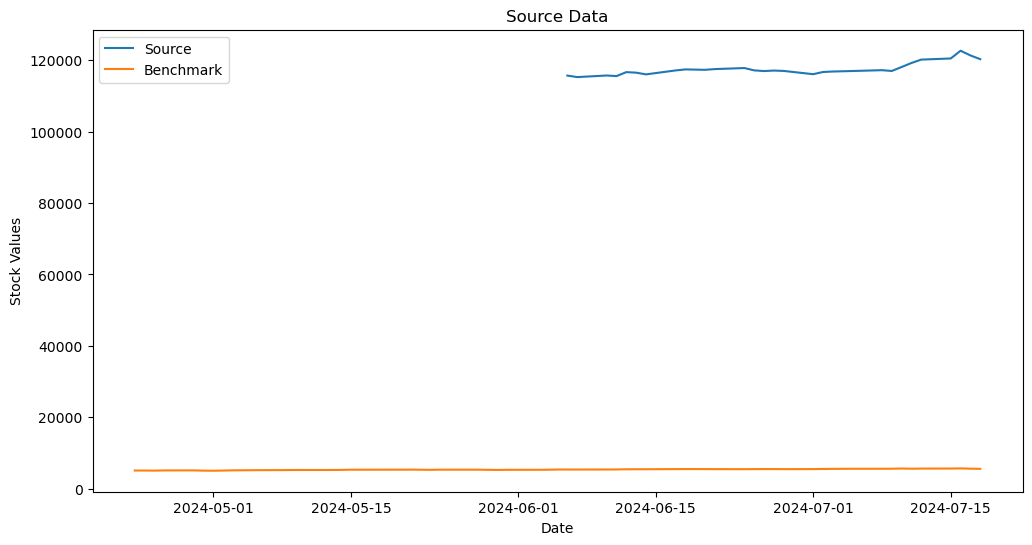

Total investment: <dwave.optimization.symbols.NaryAdd at 0x4df52388>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x4e009b48>


2025-09-02 22:20:24,557 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x4bc1b598>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:20:33,294 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:20:33,294 - inspect_results_logger - INFO - Final Sharpe ratio: 0.679833
2025-09-02 22:20:33,295 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:20:33,295 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x437dc628>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x43894038>


...

2025-09-02 22:26:54,853 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:26:54,854 - inspect_results_logger - INFO - Final Sharpe ratio: 0.909848
2025-09-02 22:26:54,854 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:26:54,854 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x3c0b2488>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x3c169cd8>


2025-09-02 22:27:00,077 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x3b08de18>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:27:06,590 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:27:06,591 - inspect_results_logger - INFO - Final Sharpe ratio: 0.773619
2025-09-02 22:27:06,591 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:27:06,592 - inspect_results_logger - INFO - All weights >= min_investment: True


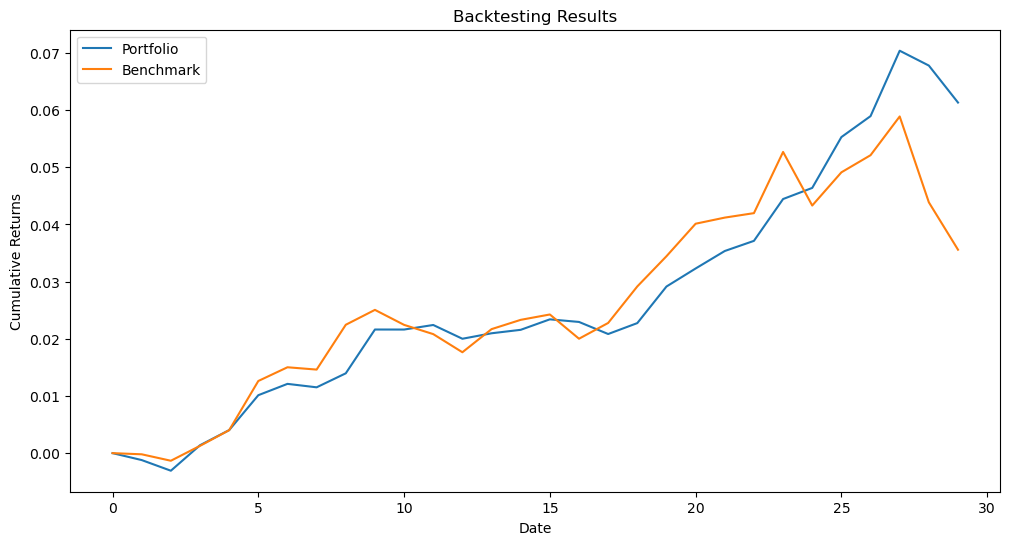

Dictionary pickled and saved to ../../results/sharpe_optimization/results_wide_4_cqm.pkl
initial date: 2023-09-27 00:00:00


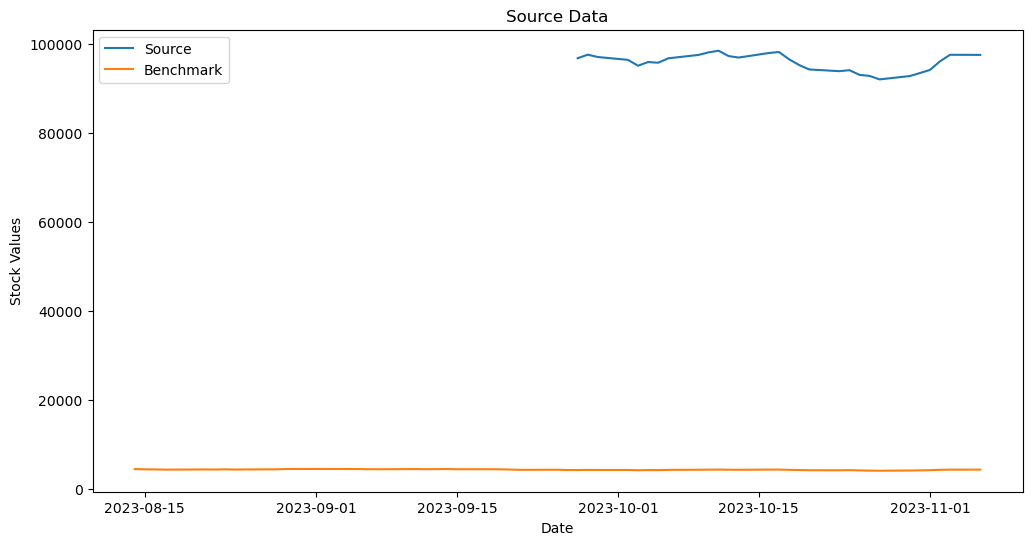

Total investment: <dwave.optimization.symbols.NaryAdd at 0x43429b18>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x434e12d8>


2025-09-02 22:27:12,024 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x3ed026b8>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:27:17,351 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:27:17,352 - inspect_results_logger - INFO - Final Sharpe ratio: 0.046721
2025-09-02 22:27:17,352 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:27:17,353 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x4a8a6918>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x4a95e428>


...

2025-09-02 22:31:56,638 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:31:56,638 - inspect_results_logger - INFO - Final Sharpe ratio: 0.220996
2025-09-02 22:31:56,638 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:31:56,639 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x4b9b8178>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x43333cb8>


2025-09-02 22:32:01,821 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x43523938>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:32:09,626 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:32:09,626 - inspect_results_logger - INFO - Final Sharpe ratio: 0.191798
2025-09-02 22:32:09,627 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:32:09,627 - inspect_results_logger - INFO - All weights >= min_investment: True


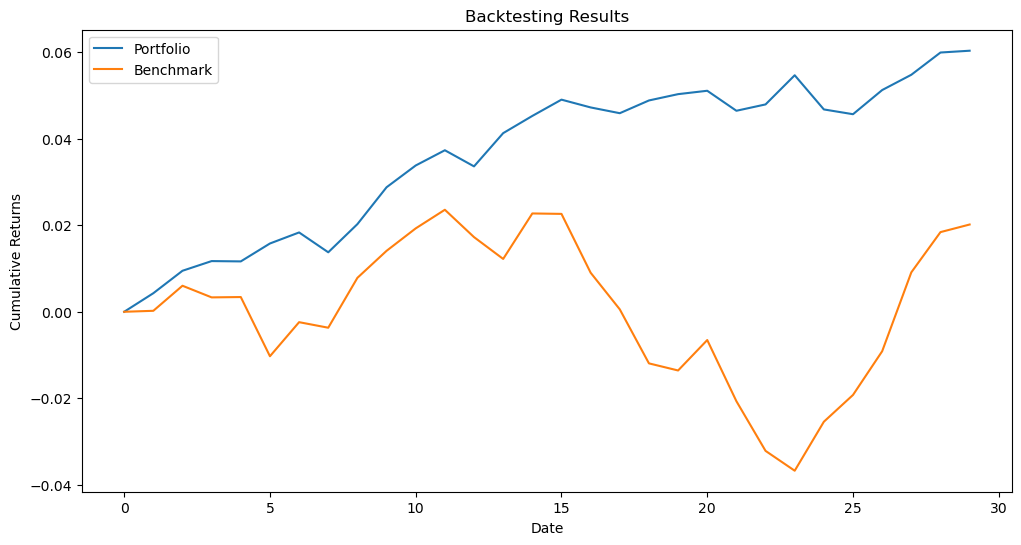

Dictionary pickled and saved to ../../results/sharpe_optimization/results_wide_5_cqm.pkl
initial date: 2019-08-05 00:00:00


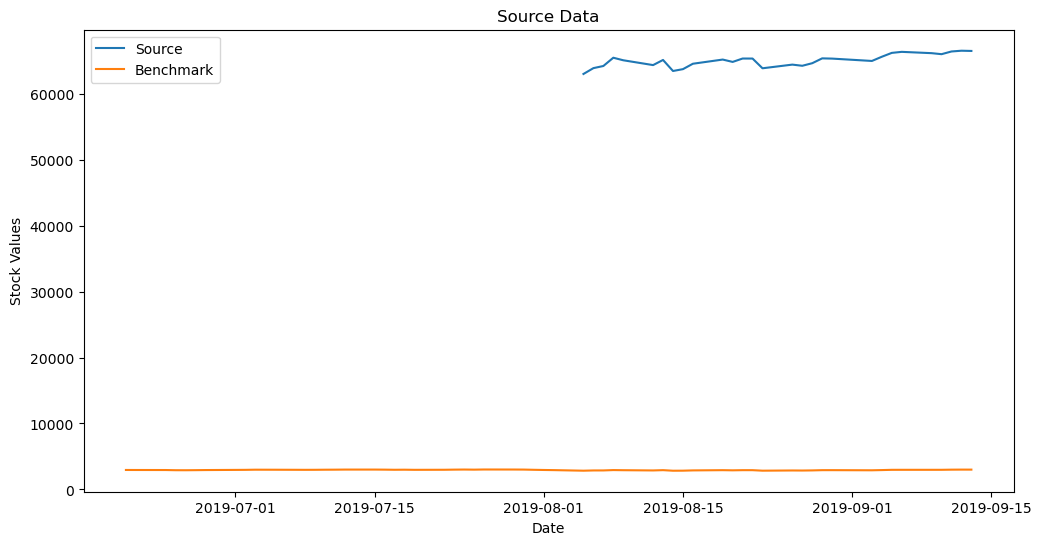

Total investment: <dwave.optimization.symbols.NaryAdd at 0x44333f58>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x443eb868>


2025-09-02 22:32:15,068 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x477ef7e8>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:32:24,370 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:32:24,371 - inspect_results_logger - INFO - Final Sharpe ratio: 0.341724
2025-09-02 22:32:24,371 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:32:24,371 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x417127e8>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x417ca448>


...

Total investment: <dwave.optimization.symbols.NaryAdd at 0x3a920678>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x3e5117b8>


2025-09-02 22:34:53,834 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x46eac4d8>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:35:08,525 - inspect_results_logger - ERROR - Optimization failed: Positive directional derivative for linesearch
2025-09-02 22:35:08,525 - inspect_results_logger - ERROR - D-Wave solver encountered an error: D-Wave optimization solver failed: Positive directional derivative for linesearch


Failed ../../results/sharpe_optimization/results_wide_6_cqm.pkl due to D-Wave quantum portfolio optimization failed: D-Wave optimization solver failed: Positive directional derivative for linesearch
Dictionary pickled and saved to ../../results/sharpe_optimization/results_wide_6_cqm.pkl
initial date: 2014-01-23 00:00:00


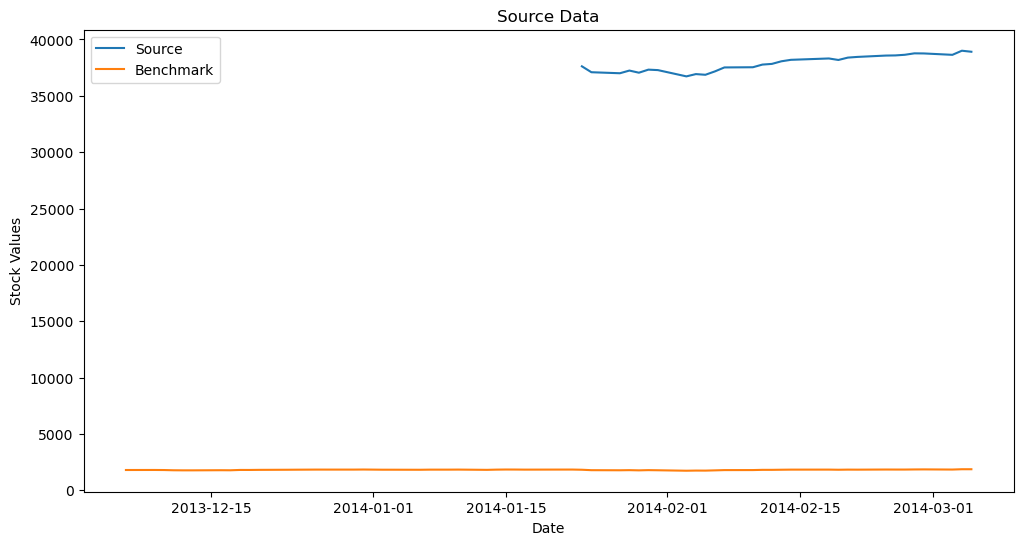

Total investment: <dwave.optimization.symbols.NaryAdd at 0x43f1e618>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x4defb138>


2025-09-02 22:35:12,097 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x4e0eb358>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:35:20,937 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:35:20,937 - inspect_results_logger - INFO - Final Sharpe ratio: 0.670303
2025-09-02 22:35:20,937 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:35:20,937 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x395815f8>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x39639198>


...

2025-09-02 22:42:07,119 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:42:07,119 - inspect_results_logger - INFO - Final Sharpe ratio: 0.789143
2025-09-02 22:42:07,119 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:42:07,119 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x3b467ed8>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x4170a928>


2025-09-02 22:42:12,325 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x53bb70e8>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:42:24,405 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:42:24,406 - inspect_results_logger - INFO - Final Sharpe ratio: 0.677282
2025-09-02 22:42:24,406 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:42:24,406 - inspect_results_logger - INFO - All weights >= min_investment: True


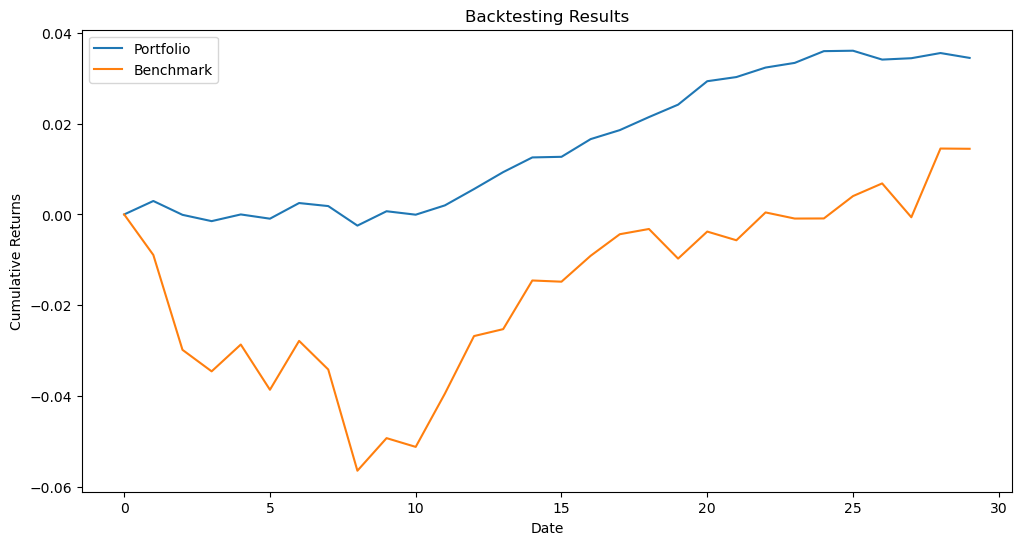

Dictionary pickled and saved to ../../results/sharpe_optimization/results_wide_7_cqm.pkl
initial date: 2016-06-01 00:00:00


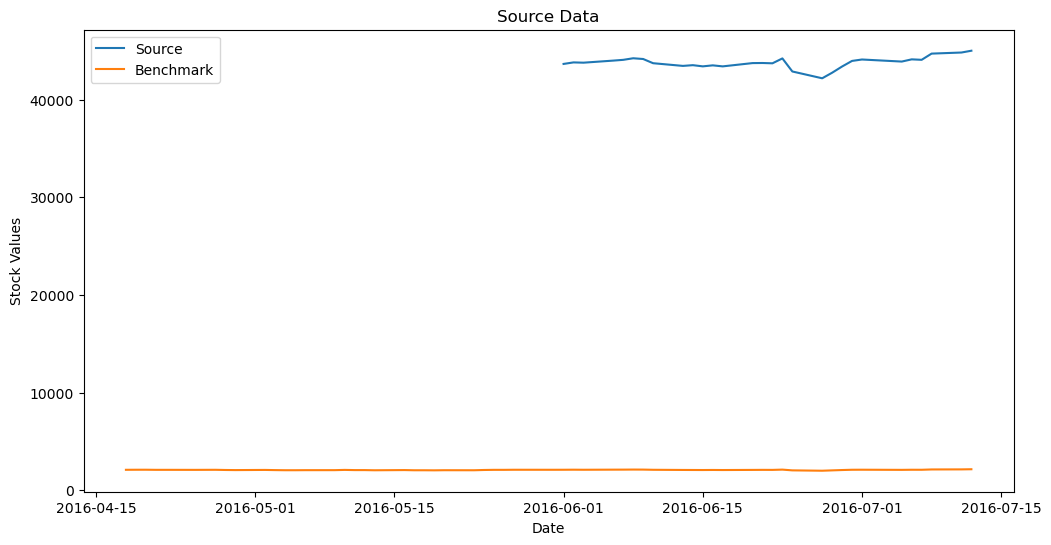

Total investment: <dwave.optimization.symbols.NaryAdd at 0x46551e98>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x466097a8>


2025-09-02 22:42:28,055 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x47ad76f8>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:42:35,420 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:42:35,421 - inspect_results_logger - INFO - Final Sharpe ratio: 0.454553
2025-09-02 22:42:35,421 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:42:35,421 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x3c2fc2a8>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x3c3f5d08>


...

2025-09-02 22:49:24,449 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:49:24,450 - inspect_results_logger - INFO - Final Sharpe ratio: 0.651046
2025-09-02 22:49:24,450 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:49:24,450 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x3f17b678>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x3f232c18>


2025-09-02 22:49:28,168 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x4949f818>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:49:38,370 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:49:38,371 - inspect_results_logger - INFO - Final Sharpe ratio: 0.651701
2025-09-02 22:49:38,372 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:49:38,372 - inspect_results_logger - INFO - All weights >= min_investment: True


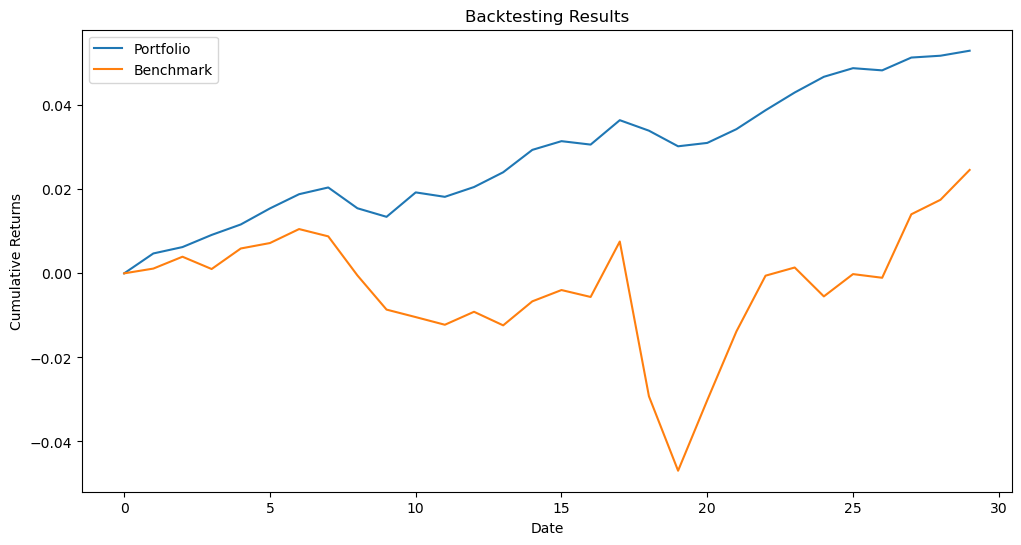

Dictionary pickled and saved to ../../results/sharpe_optimization/results_wide_8_cqm.pkl
initial date: 2021-12-30 00:00:00


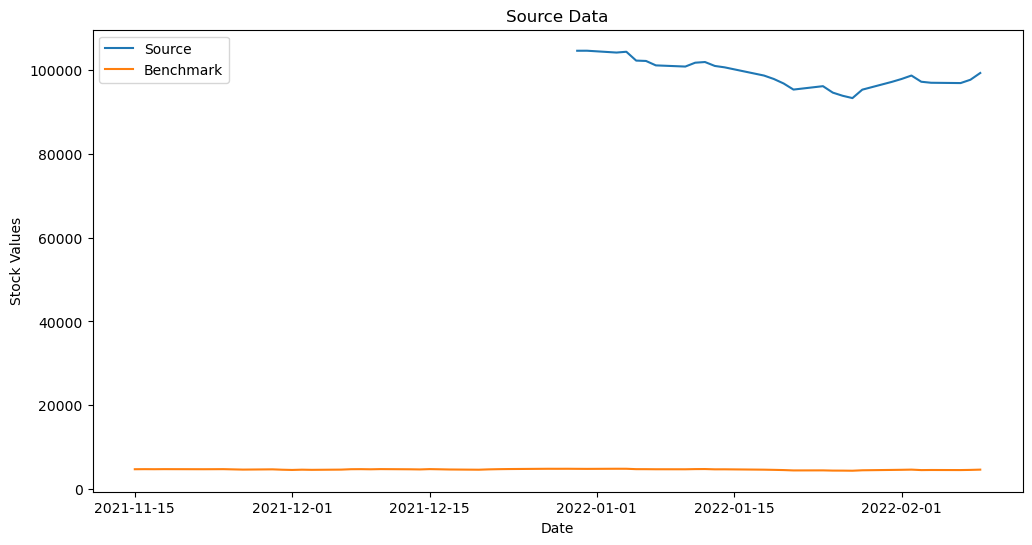

Total investment: <dwave.optimization.symbols.NaryAdd at 0x3fa36ef8>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x3faee658>


2025-09-02 22:49:43,899 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x47c5bec8>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:49:49,436 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:49:49,437 - inspect_results_logger - INFO - Final Sharpe ratio: 0.352801
2025-09-02 22:49:49,437 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:49:49,438 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x512310d8>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x512e8b28>


...

2025-09-02 22:54:30,844 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:54:30,845 - inspect_results_logger - INFO - Final Sharpe ratio: 0.244218
2025-09-02 22:54:30,845 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:54:30,846 - inspect_results_logger - INFO - All weights >= min_investment: True


Total investment: <dwave.optimization.symbols.NaryAdd at 0x4622ad98>
Portfolio return: <dwave.optimization.symbols.NaryAdd at 0x462e2628>


2025-09-02 22:54:36,370 - inspect_results_logger - INFO - Solving D-Wave optimization model...


Portfolio std: <dwave.optimization.symbols.SquareRoot at 0x4bfc3ba8>
D-Wave optimization model created successfully
Assets: 680, Scale factor: 10000


2025-09-02 22:54:37,505 - inspect_results_logger - INFO - D-Wave-inspired optimization completed successfully
2025-09-02 22:54:37,506 - inspect_results_logger - INFO - Final Sharpe ratio: 0.297408
2025-09-02 22:54:37,507 - inspect_results_logger - INFO - Weights sum: 1.000000
2025-09-02 22:54:37,507 - inspect_results_logger - INFO - All weights >= min_investment: True


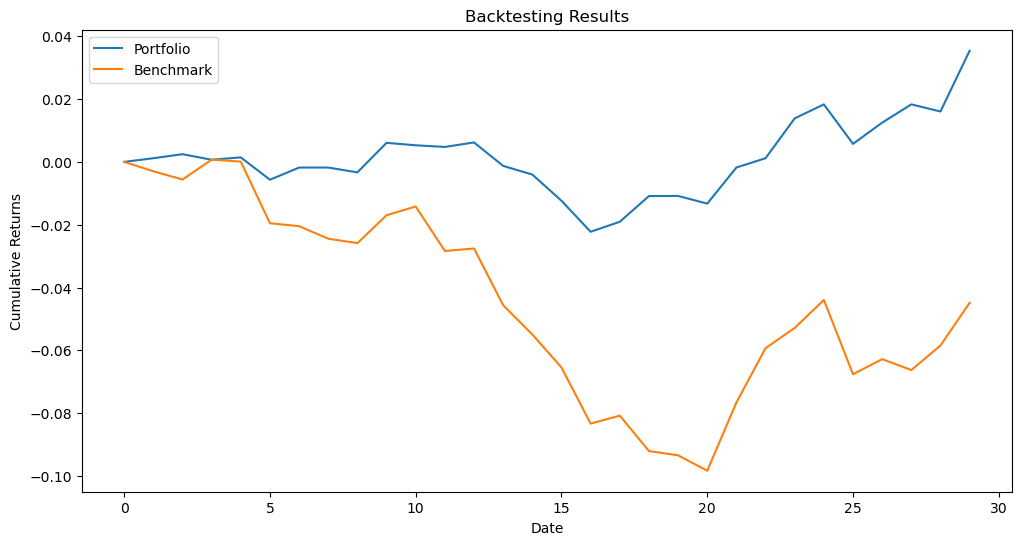

Dictionary pickled and saved to ../../results/sharpe_optimization/results_wide_9_cqm.pkl


In [22]:
results_path_cqm_wide = '../../results/sharpe_optimization/results_wide_{}_cqm.pkl'
_ = run_experiment(results_path_cqm_wide, source_wide, benchmark, opt_fun_cqm, parameters)

#### Performance Analysis for Wide Dataset

In [23]:
# Performance analysis for CQM optimization (Wide Dataset - Stocks + ETFs)
cqm_wide_solvers = [
    {'path_template': '../../results/sharpe_optimization/results_wide_{}_cqm.pkl', 'name': 'D-Wave CQM Sharpe'},
]

print("\n" + "="*100)
print("COMPREHENSIVE PERFORMANCE SUMMARY - D-Wave CQM Optimization (Wide Dataset - Stocks + ETFs)")
print("="*100)
summary_df = performance_summary(cqm_wide_solvers, n_periods)
if not summary_df.empty:
    display(summary_df)
    
    # Performance analysis
    print("\nPerformance Analysis:")
    print("-" * 50)
    print(f"Successful periods: {summary_df.iloc[0]['Periods']}/{n_periods}")
    print(f"Average return: {summary_df.iloc[0]['Avg_Return']:.4f}")
    print(f"Average execution time: {summary_df.iloc[0]['Avg_Time']:.2f}s")
    print(f"Success rate: {summary_df.iloc[0]['Success_Rate']:.1f}%")
else:
    print("No summary data available")


COMPREHENSIVE PERFORMANCE SUMMARY - D-Wave CQM Optimization (Wide Dataset - Stocks + ETFs)


,Solver,Periods,Avg_Return,Std_Return,Min_Return,Max_Return,Avg_Time,Std_Time,Success_Rate
0,D-Wave CQM Sharpe,8,0.0633,0.0235,0.0345,0.1011,364.6904,58.7914,80.0



Performance Analysis:
--------------------------------------------------
Successful periods: 8/10
Average return: 0.0633
Average execution time: 364.69s
Success rate: 80.0%


## Overall CQM Performance Summary

In [24]:
# Compare CQM performance across full and wide datasets only
all_cqm_solvers = [
    {'path_template': '../../results/sharpe_optimization/results_full_{}_cqm.pkl', 'name': 'CQM - Full Dataset'},
    {'path_template': '../../results/sharpe_optimization/results_wide_{}_cqm.pkl', 'name': 'CQM - Wide Dataset'},
]

print("\n" + "="*120)
print("OVERALL D-WAVE CQM PERFORMANCE COMPARISON - FULL AND WIDE DATASETS")
print("="*120)

summary_df = performance_summary(all_cqm_solvers, n_periods)
if not summary_df.empty:
    # Sort by average return for better readability
    summary_df_sorted = summary_df.sort_values('Avg_Return', ascending=False)
    display(summary_df_sorted)
    
    # Performance analysis
    print("\nPerformance Analysis Across Datasets:")
    print("-" * 70)
    print(f"Best performing dataset: {summary_df_sorted.iloc[0]['Solver']} (avg return: {summary_df_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest execution: {summary_df.loc[summary_df['Avg_Time'].idxmin(), 'Solver']} ({summary_df['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {summary_df.loc[summary_df['Success_Rate'].idxmax(), 'Solver']} ({summary_df['Success_Rate'].max():.1f}% success rate)")
    
    # Scaling analysis
    print("\nScaling Analysis:")
    print("-" * 40)
    for _, row in summary_df.iterrows():
        dataset_size = "439" if "Full Dataset" in row['Solver'] else "680"
        print(f"{row['Solver']:<25}: {dataset_size:>4} assets | {row['Avg_Time']:>6.2f}s | {row['Success_Rate']:>5.1f}% | {row['Avg_Return']:>8.4f}")
        
else:
    print("No summary data available")


OVERALL D-WAVE CQM PERFORMANCE COMPARISON - FULL AND WIDE DATASETS


,Solver,Periods,Avg_Return,Std_Return,Min_Return,Max_Return,Avg_Time,Std_Time,Success_Rate
0,CQM - Full Dataset,9,0.1242,0.0600,0.0767,0.2793,125.9507,18.5966,90.0
1,CQM - Wide Dataset,8,0.0633,0.0235,0.0345,0.1011,364.6904,58.7914,80.0



Performance Analysis Across Datasets:
----------------------------------------------------------------------
Best performing dataset: CQM - Full Dataset (avg return: 0.1242)
Fastest execution: CQM - Full Dataset (125.95s)
Most reliable: CQM - Full Dataset (90.0% success rate)

Scaling Analysis:
----------------------------------------
CQM - Full Dataset       :  439 assets | 125.95s |  90.0% |   0.1242
CQM - Wide Dataset       :  680 assets | 364.69s |  80.0% |   0.0633
